# Optimization Algorithms for Deep Learning
## A Comprehensive Study with Visualizations

### Algorithms Covered:
1. **Gradient Descent (GD)** — Vanilla full-batch
2. **Batch Gradient Descent (BGD)** — Mini-batch variant
3. **Momentum-Based GD** — Accelerated with velocity
4. **AdaGrad** — Adaptive learning rates
5. **NAG (Nesterov Accelerated Gradient)** — Look-ahead momentum
6. **AdaDelta** — No learning rate required
7. **Adam** — Adaptive Moment Estimation

---
**Dataset:** California Housing Dataset (sklearn) | **Task:** Linear Regression

## 📦 Imports & Setup

In [2]:
%pip install matplotlib
%pip install numpy
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

COLORS = {
    'GD':       '#ff6b6b',
    'BGD':      '#ffd93d',
    'Momentum': '#6bcb77',
    'AdaGrad':  '#4d96ff',
    'NAG':      '#c77dff',
    'AdaDelta': '#ff9f1c',
    'Adam':     '#2ec4b6'
}

print('✅ Imports successful!')

✅ Imports successful!


## 📊 Data Loading & Preprocessing

In [4]:
# Load California Housing Dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

print(f'📐 Dataset Shape: {X.shape}')
print(f'🎯 Target Shape : {y.shape}')
print(f'📋 Features     : {housing.feature_names}')
print(f'\n📈 Target Stats:')
print(f'   Min  : {y.min():.3f}')
print(f'   Max  : {y.max():.3f}')
print(f'   Mean : {y.mean():.3f}')

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Add bias column
X_train_b = np.column_stack([np.ones(len(X_train_s)), X_train_s])
X_test_b  = np.column_stack([np.ones(len(X_test_s)),  X_test_s])

N, D = X_train_b.shape
print(f'\n✅ Preprocessed — Train: {X_train_b.shape}, Test: {X_test_b.shape}')

📐 Dataset Shape: (20640, 8)
🎯 Target Shape : (20640,)
📋 Features     : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

📈 Target Stats:
   Min  : 0.150
   Max  : 5.000
   Mean : 2.069

✅ Preprocessed — Train: (16512, 9), Test: (4128, 9)


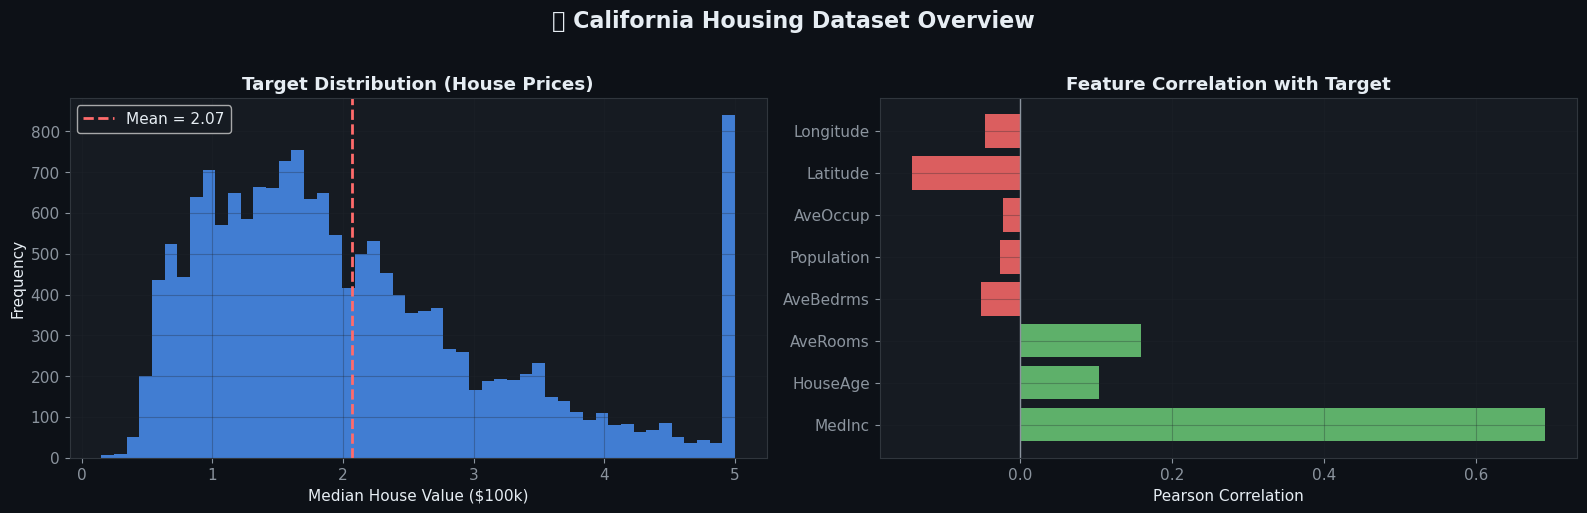

✅ Dataset overview plotted!


In [7]:
# Dataset Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📊 California Housing Dataset Overview', fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

# Distribution
ax1 = axes[0]
ax1.hist(y_train, bins=50, color='#4d96ff', alpha=0.8, edgecolor='none')
ax1.axvline(y_train.mean(), color='#ff6b6b', linewidth=2, linestyle='--', label=f'Mean = {y_train.mean():.2f}')
ax1.set_title('Target Distribution (House Prices)', fontweight='bold')
ax1.set_xlabel('Median House Value ($100k)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature correlation with target
ax2 = axes[1]
correlations = [np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(X_train.shape[1])]
colors_bar = ['#6bcb77' if c > 0 else '#ff6b6b' for c in correlations]
bars = ax2.barh(housing.feature_names, correlations, color=colors_bar, alpha=0.85)
ax2.axvline(0, color='#8b949e', linewidth=1)
ax2.set_title('Feature Correlation with Target', fontweight='bold')
ax2.set_xlabel('Pearson Correlation')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

output_path = '/mnt/user-data/outputs/dataset_overview.png'
import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)

plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Dataset overview plotted!')

## 🔧 Helper Functions

In [8]:
def mse_loss(X, y, w):
    """Compute Mean Squared Error Loss"""
    predictions = X @ w
    error = predictions - y
    return np.mean(error ** 2)

def compute_gradient(X, y, w):
    """Compute full gradient"""
    n = len(y)
    predictions = X @ w
    error = predictions - y
    return (2 / n) * X.T @ error

def compute_gradient_batch(X_batch, y_batch, w):
    """Compute gradient on a mini-batch"""
    n = len(y_batch)
    predictions = X_batch @ w
    error = predictions - y_batch
    return (2 / n) * X_batch.T @ error

def plot_training_curve(ax, losses, color, label, title, epochs):
    """Reusable plot for training loss curve"""
    x = np.arange(1, len(losses) + 1)
    ax.plot(x, losses, color=color, linewidth=2, label=label)
    ax.fill_between(x, losses, alpha=0.15, color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.set_xlim([1, epochs])

EPOCHS = 200
np.random.seed(42)
w_init = np.zeros(D)  # Shared initialization for fair comparison

# Store all results for final comparison
all_results = {}

print('✅ Helper functions defined! Ready to train.')

✅ Helper functions defined! Ready to train.


---
## 1️⃣ Gradient Descent (Vanilla / Full-Batch GD)

> **Concept:** Compute gradient over the **entire dataset** and update weights once per epoch.
>
> **Update Rule:**
> $$w = w - \alpha \cdot \nabla L(w)$$
>
> - ✅ Stable convergence
> - ❌ Slow on large datasets
> - ❌ Gets stuck in local minima easily

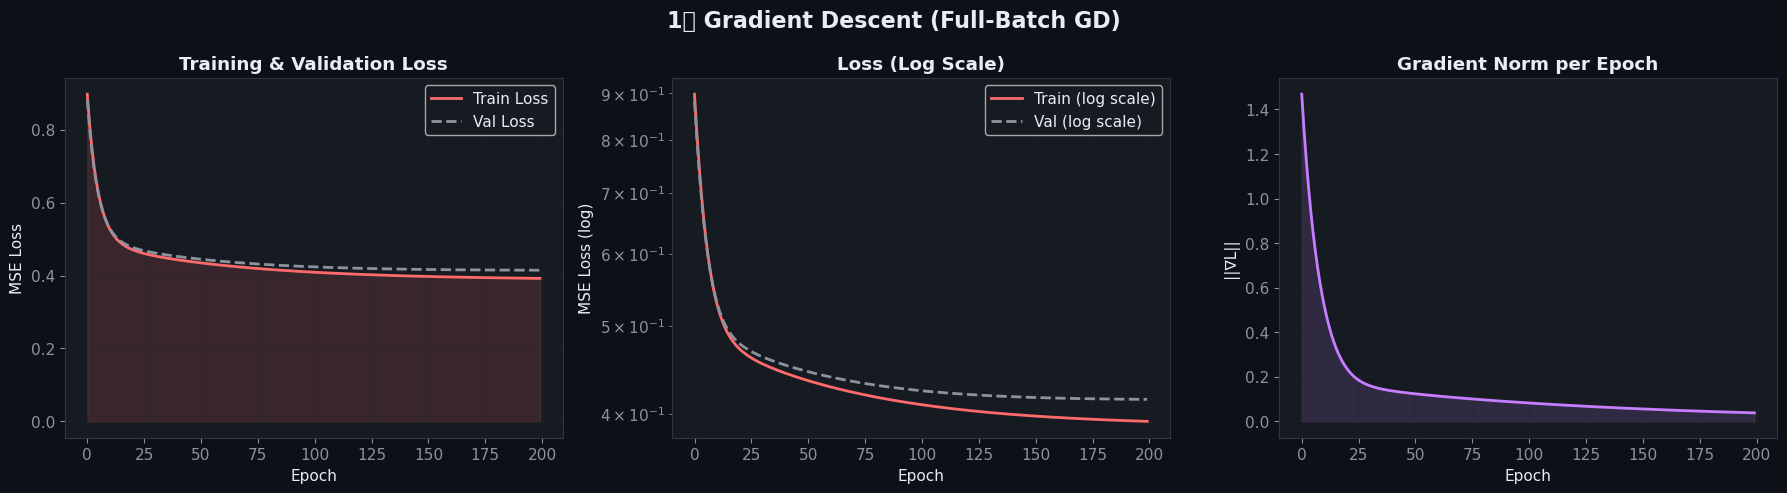

✅ GD Final Train Loss: 0.392391 | Val Loss: 0.414861


In [9]:
def gradient_descent(X, y, X_val, y_val, lr=0.01, epochs=EPOCHS):
    w = w_init.copy()
    train_losses, val_losses, grad_norms = [], [], []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, w)
        w -= lr * grad

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))

    return w, train_losses, val_losses, grad_norms

# Train
w_gd, train_gd, val_gd, gnorm_gd = gradient_descent(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05)
all_results['GD'] = {'train': train_gd, 'val': val_gd, 'gnorm': gnorm_gd}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('1️⃣ Gradient Descent (Full-Batch GD)', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['GD']

# Loss curve
axes[0].plot(train_gd, color=color, lw=2, label='Train Loss')
axes[0].plot(val_gd, color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[0].fill_between(range(EPOCHS), train_gd, alpha=0.15, color=color)
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Log scale
axes[1].semilogy(train_gd, color=color, lw=2, label='Train (log scale)')
axes[1].semilogy(val_gd, color='#8b949e', lw=2, linestyle='--', label='Val (log scale)')
axes[1].set_title('Loss (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss (log)')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Gradient norm
axes[2].plot(gnorm_gd, color='#c77dff', lw=2)
axes[2].fill_between(range(EPOCHS), gnorm_gd, alpha=0.15, color='#c77dff')
axes[2].set_title('Gradient Norm per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('||∇L||')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/01_gradient_descent.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ GD Final Train Loss: {train_gd[-1]:.6f} | Val Loss: {val_gd[-1]:.6f}')

---
## 2️⃣ Batch Gradient Descent (Mini-Batch GD)

> **Concept:** Split data into **mini-batches**, compute gradient per batch, update weights each mini-batch.
>
> **Update Rule:**
> $$w = w - \alpha \cdot \nabla L_{batch}(w)$$
>
> - ✅ Faster convergence than full GD
> - ✅ Less memory usage
> - ✅ Noisy updates help escape local minima

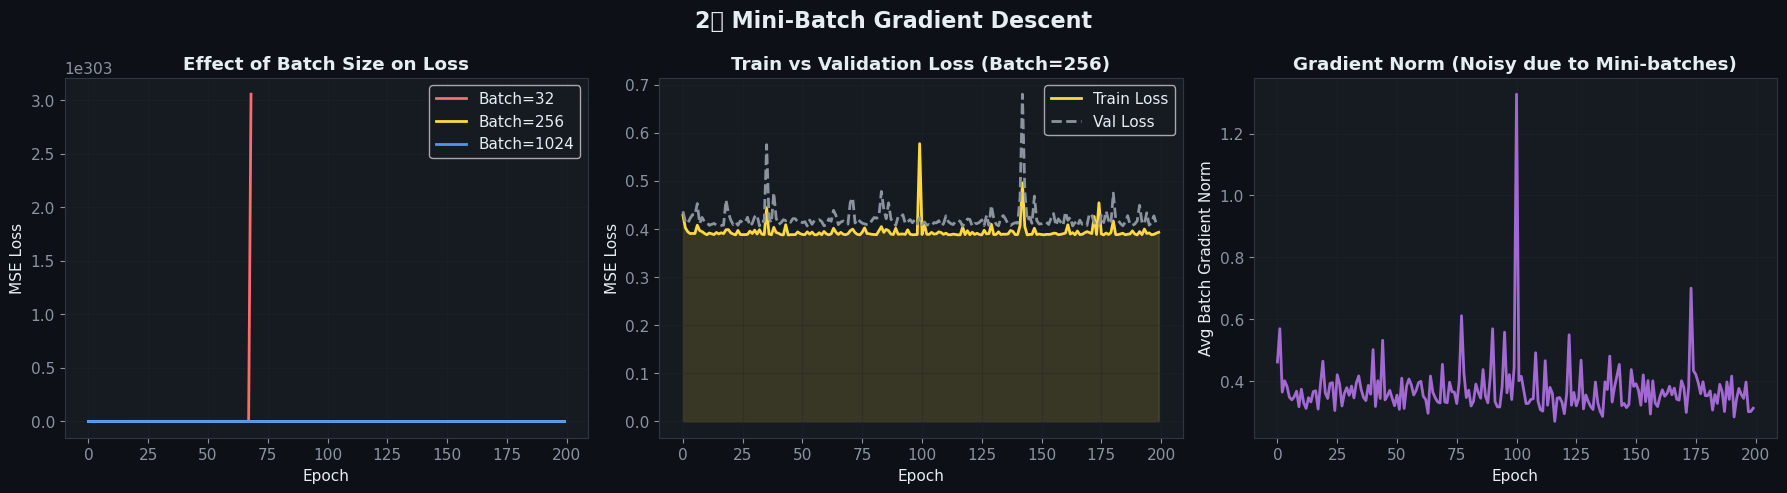

✅ Mini-BGD Final Train Loss: 0.393260 | Val Loss: 0.410725


In [10]:
def mini_batch_gd(X, y, X_val, y_val, lr=0.01, epochs=EPOCHS, batch_size=256):
    w = w_init.copy()
    train_losses, val_losses, grad_norms = [], [], []
    n = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuf, y_shuf = X[indices], y[indices]
        epoch_grad_norm = 0

        for start in range(0, n, batch_size):
            X_b = X_shuf[start:start + batch_size]
            y_b = y_shuf[start:start + batch_size]
            grad = compute_gradient_batch(X_b, y_b, w)
            w -= lr * grad
            epoch_grad_norm += np.linalg.norm(grad)

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(epoch_grad_norm / (n // batch_size))

    return w, train_losses, val_losses, grad_norms

# Train with different batch sizes
w_bgd, train_bgd, val_bgd, gnorm_bgd = mini_batch_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, batch_size=256)
_, train_bgd_32, val_bgd_32, _ = mini_batch_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, batch_size=32)
_, train_bgd_1024, val_bgd_1024, _ = mini_batch_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, batch_size=1024)
all_results['BGD'] = {'train': train_bgd, 'val': val_bgd, 'gnorm': gnorm_bgd}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2️⃣ Mini-Batch Gradient Descent', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['BGD']

# Batch size comparison
axes[0].plot(train_bgd_32,   color='#ff6b6b', lw=2, label='Batch=32')
axes[0].plot(train_bgd,      color=color,     lw=2, label='Batch=256')
axes[0].plot(train_bgd_1024, color='#4d96ff', lw=2, label='Batch=1024')
axes[0].set_title('Effect of Batch Size on Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_bgd, color=color, lw=2, label='Train Loss')
axes[1].plot(val_bgd, color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_bgd, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss (Batch=256)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Grad norm
axes[2].plot(gnorm_bgd, color='#c77dff', lw=2, alpha=0.8)
axes[2].set_title('Gradient Norm (Noisy due to Mini-batches)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Avg Batch Gradient Norm')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/02_mini_batch_gd.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ Mini-BGD Final Train Loss: {train_bgd[-1]:.6f} | Val Loss: {val_bgd[-1]:.6f}')

---
## 3️⃣ Momentum-Based Gradient Descent

> **Concept:** Accumulate a **velocity vector** in the direction of gradients. Helps accelerate GD and dampen oscillations.
>
> **Update Rule:**
> $$v_t = \beta v_{t-1} + \alpha \nabla L(w)$$
> $$w = w - v_t$$
>
> - ✅ Faster convergence
> - ✅ Reduces oscillation
> - ⚠️ May overshoot minimum

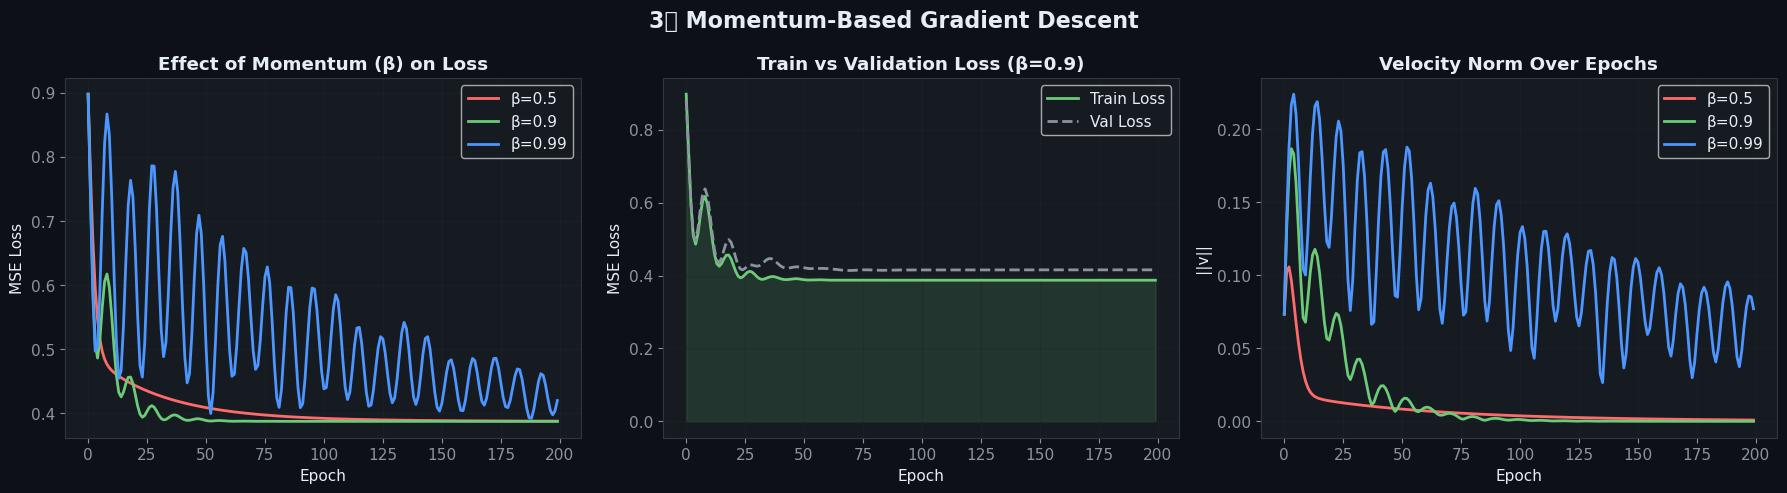

✅ Momentum Final Train Loss: 0.387449 | Val Loss: 0.415844


In [11]:
def momentum_gd(X, y, X_val, y_val, lr=0.01, beta=0.9, epochs=EPOCHS):
    w = w_init.copy()
    v = np.zeros_like(w)
    train_losses, val_losses, grad_norms, velocities = [], [], [], []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, w)
        v = beta * v + lr * grad
        w -= v

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))
        velocities.append(np.linalg.norm(v))

    return w, train_losses, val_losses, grad_norms, velocities

# Train with different beta values
w_mom, train_mom, val_mom, gnorm_mom, vel_mom = momentum_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, beta=0.9)
_, train_mom_b5, _, _, vel_b5 = momentum_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, beta=0.5)
_, train_mom_b99, _, _, vel_b99 = momentum_gd(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, beta=0.99)
all_results['Momentum'] = {'train': train_mom, 'val': val_mom, 'gnorm': gnorm_mom}

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3️⃣ Momentum-Based Gradient Descent', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['Momentum']

# Beta comparison
axes[0].plot(train_mom_b5,  color='#ff6b6b', lw=2, label='β=0.5')
axes[0].plot(train_mom,     color=color,     lw=2, label='β=0.9')
axes[0].plot(train_mom_b99, color='#4d96ff', lw=2, label='β=0.99')
axes[0].set_title('Effect of Momentum (β) on Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_mom, color=color, lw=2, label='Train Loss')
axes[1].plot(val_mom, color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_mom, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss (β=0.9)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Velocity norm over time
axes[2].plot(vel_b5,  color='#ff6b6b', lw=2, label='β=0.5')
axes[2].plot(vel_mom, color=color,     lw=2, label='β=0.9')
axes[2].plot(vel_b99, color='#4d96ff', lw=2, label='β=0.99')
axes[2].set_title('Velocity Norm Over Epochs', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('||v||')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/03_momentum_gd.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ Momentum Final Train Loss: {train_mom[-1]:.6f} | Val Loss: {val_mom[-1]:.6f}')

---
## 4️⃣ AdaGrad (Adaptive Gradient Algorithm)

> **Concept:** Adapts the learning rate **per parameter** using historical gradient sum-of-squares.
>
> **Update Rule:**
> $$G_t = G_{t-1} + (\nabla L)^2$$
> $$w = w - \frac{\alpha}{\sqrt{G_t + \epsilon}} \cdot \nabla L$$
>
> - ✅ Great for sparse data
> - ✅ No manual learning rate tuning per param
> - ❌ Learning rate can vanish over time

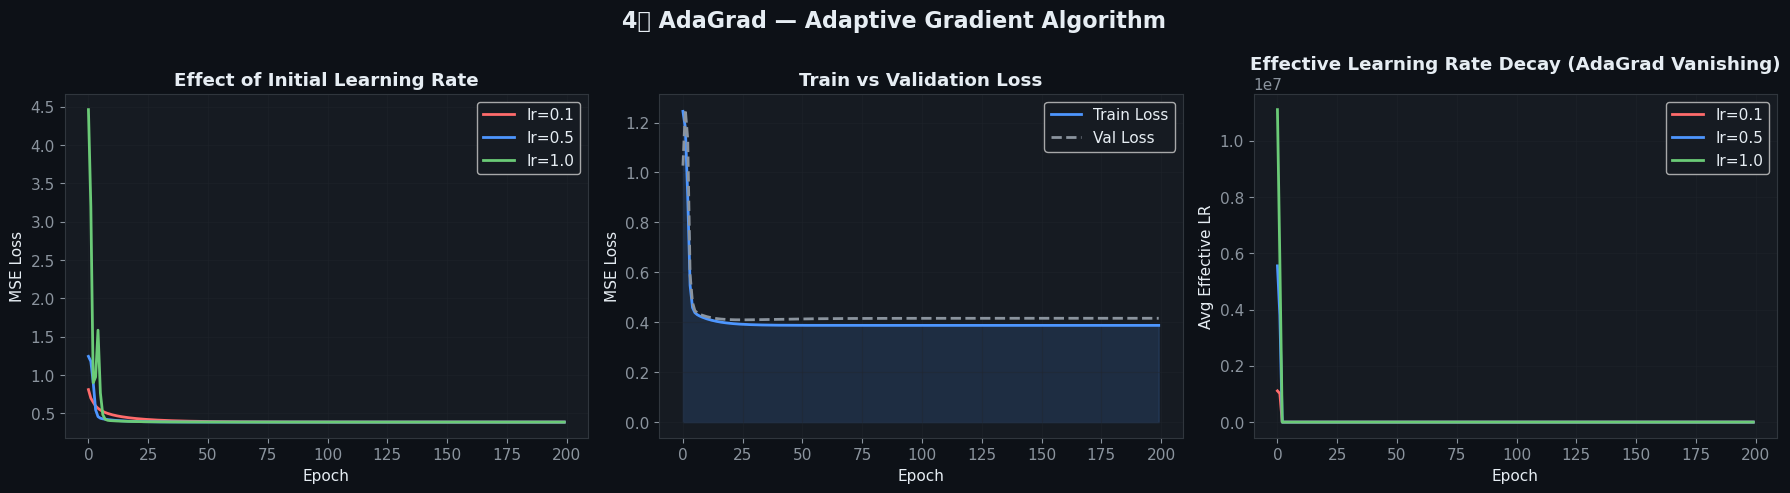

✅ AdaGrad Final Train Loss: 0.387449 | Val Loss: 0.415843


In [12]:
def adagrad(X, y, X_val, y_val, lr=0.1, eps=1e-8, epochs=EPOCHS):
    w = w_init.copy()
    G = np.zeros_like(w)  # Accumulated squared gradients
    train_losses, val_losses, grad_norms, eff_lrs = [], [], [], []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, w)
        G += grad ** 2
        adapted_lr = lr / (np.sqrt(G) + eps)
        w -= adapted_lr * grad

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))
        eff_lrs.append(np.mean(adapted_lr))  # Average effective LR

    return w, train_losses, val_losses, grad_norms, eff_lrs

w_ada, train_ada, val_ada, gnorm_ada, elr_ada = adagrad(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.5)
_, train_ada_01, _, _, elr_01 = adagrad(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.1)
_, train_ada_10, _, _, elr_10 = adagrad(X_train_b, y_train_s, X_test_b, y_test_s, lr=1.0)
all_results['AdaGrad'] = {'train': train_ada, 'val': val_ada, 'gnorm': gnorm_ada}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4️⃣ AdaGrad — Adaptive Gradient Algorithm', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['AdaGrad']

# LR comparison
axes[0].plot(train_ada_01, color='#ff6b6b', lw=2, label='lr=0.1')
axes[0].plot(train_ada,    color=color,     lw=2, label='lr=0.5')
axes[0].plot(train_ada_10, color='#6bcb77', lw=2, label='lr=1.0')
axes[0].set_title('Effect of Initial Learning Rate', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_ada, color=color, lw=2, label='Train Loss')
axes[1].plot(val_ada,   color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_ada, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Effective LR decay
axes[2].plot(elr_01, color='#ff6b6b', lw=2, label='lr=0.1')
axes[2].plot(elr_ada, color=color,    lw=2, label='lr=0.5')
axes[2].plot(elr_10, color='#6bcb77', lw=2, label='lr=1.0')
axes[2].set_title('Effective Learning Rate Decay (AdaGrad Vanishing)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Avg Effective LR')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/04_adagrad.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ AdaGrad Final Train Loss: {train_ada[-1]:.6f} | Val Loss: {val_ada[-1]:.6f}')

---
## 5️⃣ NAG — Nesterov Accelerated Gradient

> **Concept:** A smarter momentum method. Instead of computing gradient at current position, it computes at **lookahead position** (where momentum would take us).
>
> **Update Rule:**
> $$\tilde{w} = w - \beta v_{t-1}$$
> $$v_t = \beta v_{t-1} + \alpha \nabla L(\tilde{w})$$
> $$w = w - v_t$$
>
> - ✅ More responsive than standard momentum
> - ✅ Better convergence guarantees
> - ⚠️ Slightly more complex to implement

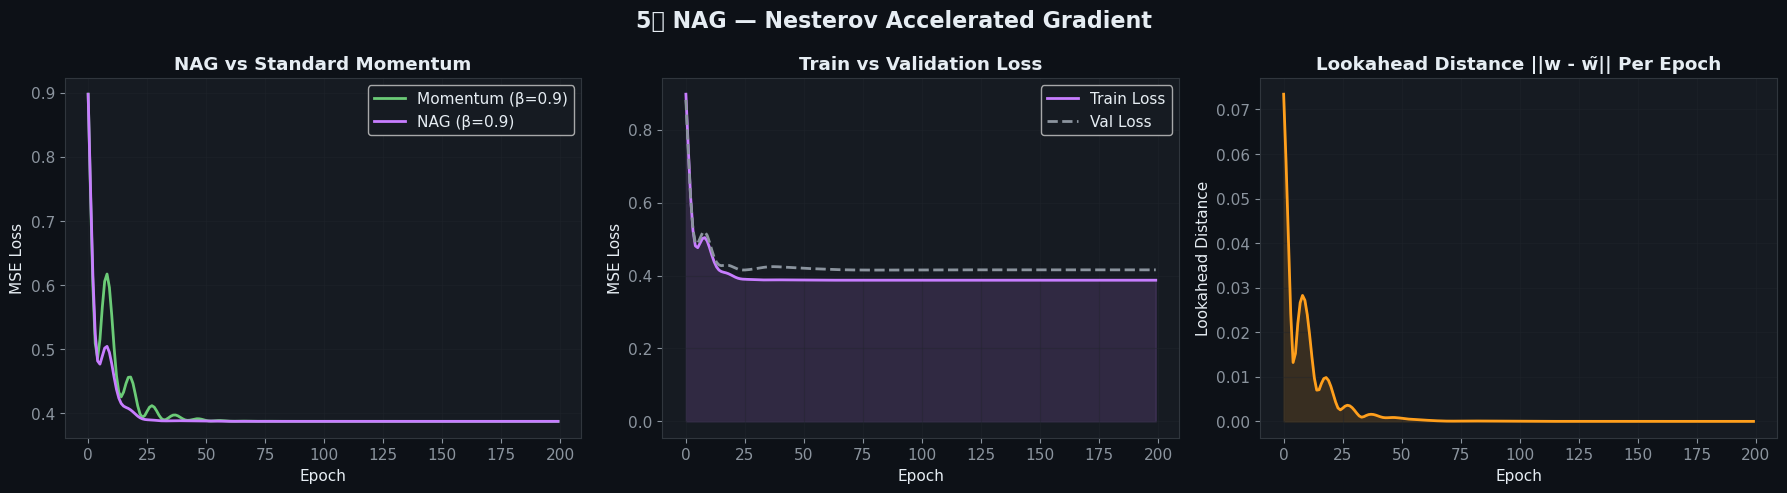

✅ NAG Final Train Loss: 0.387449 | Val Loss: 0.415844


In [13]:
def nag(X, y, X_val, y_val, lr=0.01, beta=0.9, epochs=EPOCHS):
    w = w_init.copy()
    v = np.zeros_like(w)
    train_losses, val_losses, grad_norms, lookahead_diffs = [], [], [], []

    for epoch in range(epochs):
        # Lookahead position
        w_lookahead = w - beta * v
        # Gradient at lookahead
        grad = compute_gradient(X, y, w_lookahead)
        # Velocity update
        v = beta * v + lr * grad
        # Weight update
        w -= v

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))
        lookahead_diffs.append(np.linalg.norm(w - w_lookahead))

    return w, train_losses, val_losses, grad_norms, lookahead_diffs

w_nag, train_nag, val_nag, gnorm_nag, la_nag = nag(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.05, beta=0.9)
all_results['NAG'] = {'train': train_nag, 'val': val_nag, 'gnorm': gnorm_nag}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('5️⃣ NAG — Nesterov Accelerated Gradient', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['NAG']

# NAG vs Momentum comparison
axes[0].plot(train_mom, color=COLORS['Momentum'], lw=2, label='Momentum (β=0.9)')
axes[0].plot(train_nag, color=color,              lw=2, label='NAG (β=0.9)')
axes[0].set_title('NAG vs Standard Momentum', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_nag, color=color, lw=2, label='Train Loss')
axes[1].plot(val_nag, color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_nag, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Lookahead difference
axes[2].plot(la_nag, color='#ff9f1c', lw=2)
axes[2].fill_between(range(EPOCHS), la_nag, alpha=0.15, color='#ff9f1c')
axes[2].set_title('Lookahead Distance ||w - w̃|| Per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Lookahead Distance')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/05_nag.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ NAG Final Train Loss: {train_nag[-1]:.6f} | Val Loss: {val_nag[-1]:.6f}')

---
## 6️⃣ AdaDelta

> **Concept:** Extension of AdaGrad that **eliminates the need for a global learning rate** by using a windowed average of gradients and updates.
>
> **Update Rule:**
> $$E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho)(\nabla L)^2$$
> $$\Delta w = -\frac{\sqrt{E[\Delta w^2]_{t-1} + \epsilon}}{\sqrt{E[g^2]_t + \epsilon}} \cdot \nabla L$$
> $$E[\Delta w^2]_t = \rho E[\Delta w^2]_{t-1} + (1-\rho)(\Delta w)^2$$
>
> - ✅ No learning rate needed
> - ✅ Solves AdaGrad vanishing LR
> - ⚠️ Can be slower to start

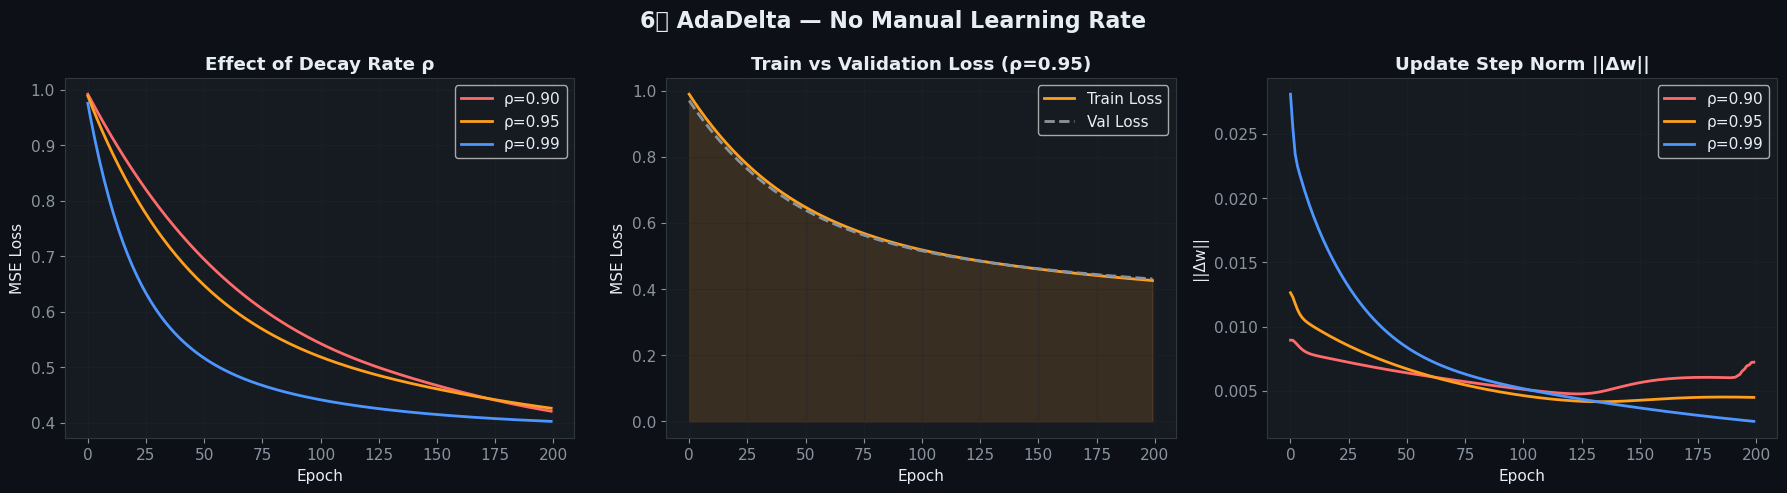

✅ AdaDelta Final Train Loss: 0.425768 | Val Loss: 0.430620


In [14]:
def adadelta(X, y, X_val, y_val, rho=0.95, eps=1e-6, epochs=EPOCHS):
    w = w_init.copy()
    E_g2   = np.zeros_like(w)  # Running avg of squared gradients
    E_dw2  = np.zeros_like(w)  # Running avg of squared updates
    train_losses, val_losses, grad_norms, update_norms = [], [], [], []

    for epoch in range(epochs):
        grad = compute_gradient(X, y, w)

        E_g2 = rho * E_g2 + (1 - rho) * grad ** 2
        delta_w = -(np.sqrt(E_dw2 + eps) / np.sqrt(E_g2 + eps)) * grad
        E_dw2 = rho * E_dw2 + (1 - rho) * delta_w ** 2
        w += delta_w

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))
        update_norms.append(np.linalg.norm(delta_w))

    return w, train_losses, val_losses, grad_norms, update_norms

w_addelta, train_addelta, val_addelta, gnorm_addelta, upd_addelta = adadelta(X_train_b, y_train_s, X_test_b, y_test_s, rho=0.95)
_, train_add_90, _, _, upd_90 = adadelta(X_train_b, y_train_s, X_test_b, y_test_s, rho=0.90)
_, train_add_99, _, _, upd_99 = adadelta(X_train_b, y_train_s, X_test_b, y_test_s, rho=0.99)
all_results['AdaDelta'] = {'train': train_addelta, 'val': val_addelta, 'gnorm': gnorm_addelta}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('6️⃣ AdaDelta — No Manual Learning Rate', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['AdaDelta']

# Rho comparison
axes[0].plot(train_add_90,  color='#ff6b6b', lw=2, label='ρ=0.90')
axes[0].plot(train_addelta, color=color,     lw=2, label='ρ=0.95')
axes[0].plot(train_add_99,  color='#4d96ff', lw=2, label='ρ=0.99')
axes[0].set_title('Effect of Decay Rate ρ', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_addelta, color=color, lw=2, label='Train Loss')
axes[1].plot(val_addelta,   color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_addelta, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss (ρ=0.95)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Update norms
axes[2].plot(upd_90,       color='#ff6b6b', lw=2, label='ρ=0.90')
axes[2].plot(upd_addelta,  color=color,     lw=2, label='ρ=0.95')
axes[2].plot(upd_99,       color='#4d96ff', lw=2, label='ρ=0.99')
axes[2].set_title('Update Step Norm ||Δw||', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('||Δw||')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/06_adadelta.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ AdaDelta Final Train Loss: {train_addelta[-1]:.6f} | Val Loss: {val_addelta[-1]:.6f}')

---
## 7️⃣ Adam — Adaptive Moment Estimation

> **Concept:** Combines momentum (1st moment) and RMSProp (2nd moment) with **bias correction**. The most widely used optimizer.
>
> **Update Rule:**
> $$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla L$$
> $$v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla L)^2$$
> $$\hat{m} = \frac{m_t}{1-\beta_1^t}, \quad \hat{v} = \frac{v_t}{1-\beta_2^t}$$
> $$w = w - \frac{\alpha}{\sqrt{\hat{v}} + \epsilon} \hat{m}$$
>
> - ✅ Combines best of Momentum + AdaGrad
> - ✅ Bias correction for early steps
> - ✅ Works well across most problems

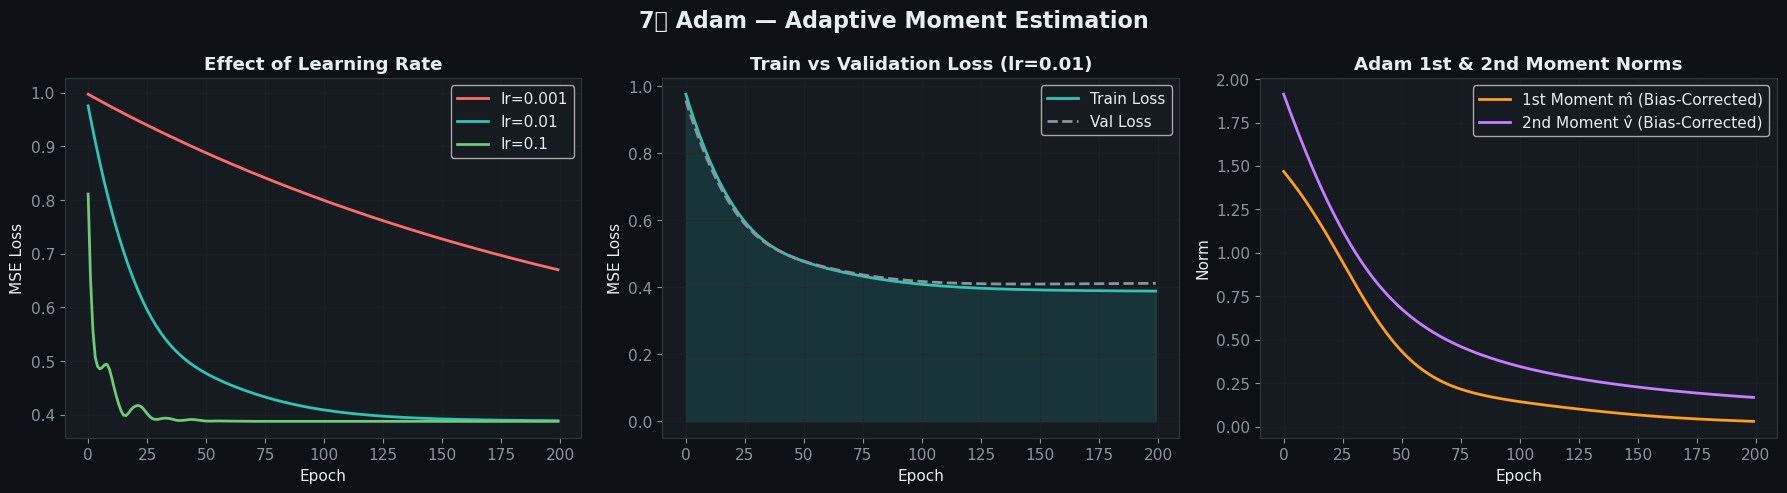

✅ Adam Final Train Loss: 0.388630 | Val Loss: 0.411778


In [15]:
def adam(X, y, X_val, y_val, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, epochs=EPOCHS):
    w = w_init.copy()
    m = np.zeros_like(w)  # 1st moment (mean)
    v = np.zeros_like(w)  # 2nd moment (variance)
    train_losses, val_losses, grad_norms, m1_norms, m2_norms = [], [], [], [], []

    for t in range(1, epochs + 1):
        grad = compute_gradient(X, y, w)

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad ** 2

        # Bias correction
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        train_losses.append(mse_loss(X, y, w))
        val_losses.append(mse_loss(X_val, y_val, w))
        grad_norms.append(np.linalg.norm(grad))
        m1_norms.append(np.linalg.norm(m_hat))
        m2_norms.append(np.linalg.norm(v_hat))

    return w, train_losses, val_losses, grad_norms, m1_norms, m2_norms

w_adam, train_adam, val_adam, gnorm_adam, m1_adam, m2_adam = adam(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.01)
_, train_adam_001, _, _, _, _ = adam(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.001)
_, train_adam_1, _, _, _, _   = adam(X_train_b, y_train_s, X_test_b, y_test_s, lr=0.1)
all_results['Adam'] = {'train': train_adam, 'val': val_adam, 'gnorm': gnorm_adam}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('7️⃣ Adam — Adaptive Moment Estimation', fontsize=16, fontweight='bold', color='#e6edf3')

color = COLORS['Adam']

# LR comparison
axes[0].plot(train_adam_001, color='#ff6b6b', lw=2, label='lr=0.001')
axes[0].plot(train_adam,     color=color,     lw=2, label='lr=0.01')
axes[0].plot(train_adam_1,   color='#6bcb77', lw=2, label='lr=0.1')
axes[0].set_title('Effect of Learning Rate', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Train vs Val
axes[1].plot(train_adam, color=color, lw=2, label='Train Loss')
axes[1].plot(val_adam,   color='#8b949e', lw=2, linestyle='--', label='Val Loss')
axes[1].fill_between(range(EPOCHS), train_adam, alpha=0.15, color=color)
axes[1].set_title('Train vs Validation Loss (lr=0.01)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Moment norms
axes[2].plot(m1_adam, color='#ff9f1c', lw=2, label='1st Moment m̂ (Bias-Corrected)')
axes[2].plot(m2_adam, color='#c77dff', lw=2, label='2nd Moment v̂ (Bias-Corrected)')
axes[2].set_title('Adam 1st & 2nd Moment Norms', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Norm')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/07_adam.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'✅ Adam Final Train Loss: {train_adam[-1]:.6f} | Val Loss: {val_adam[-1]:.6f}')

---
## 📊 Final Comparison — All Algorithms

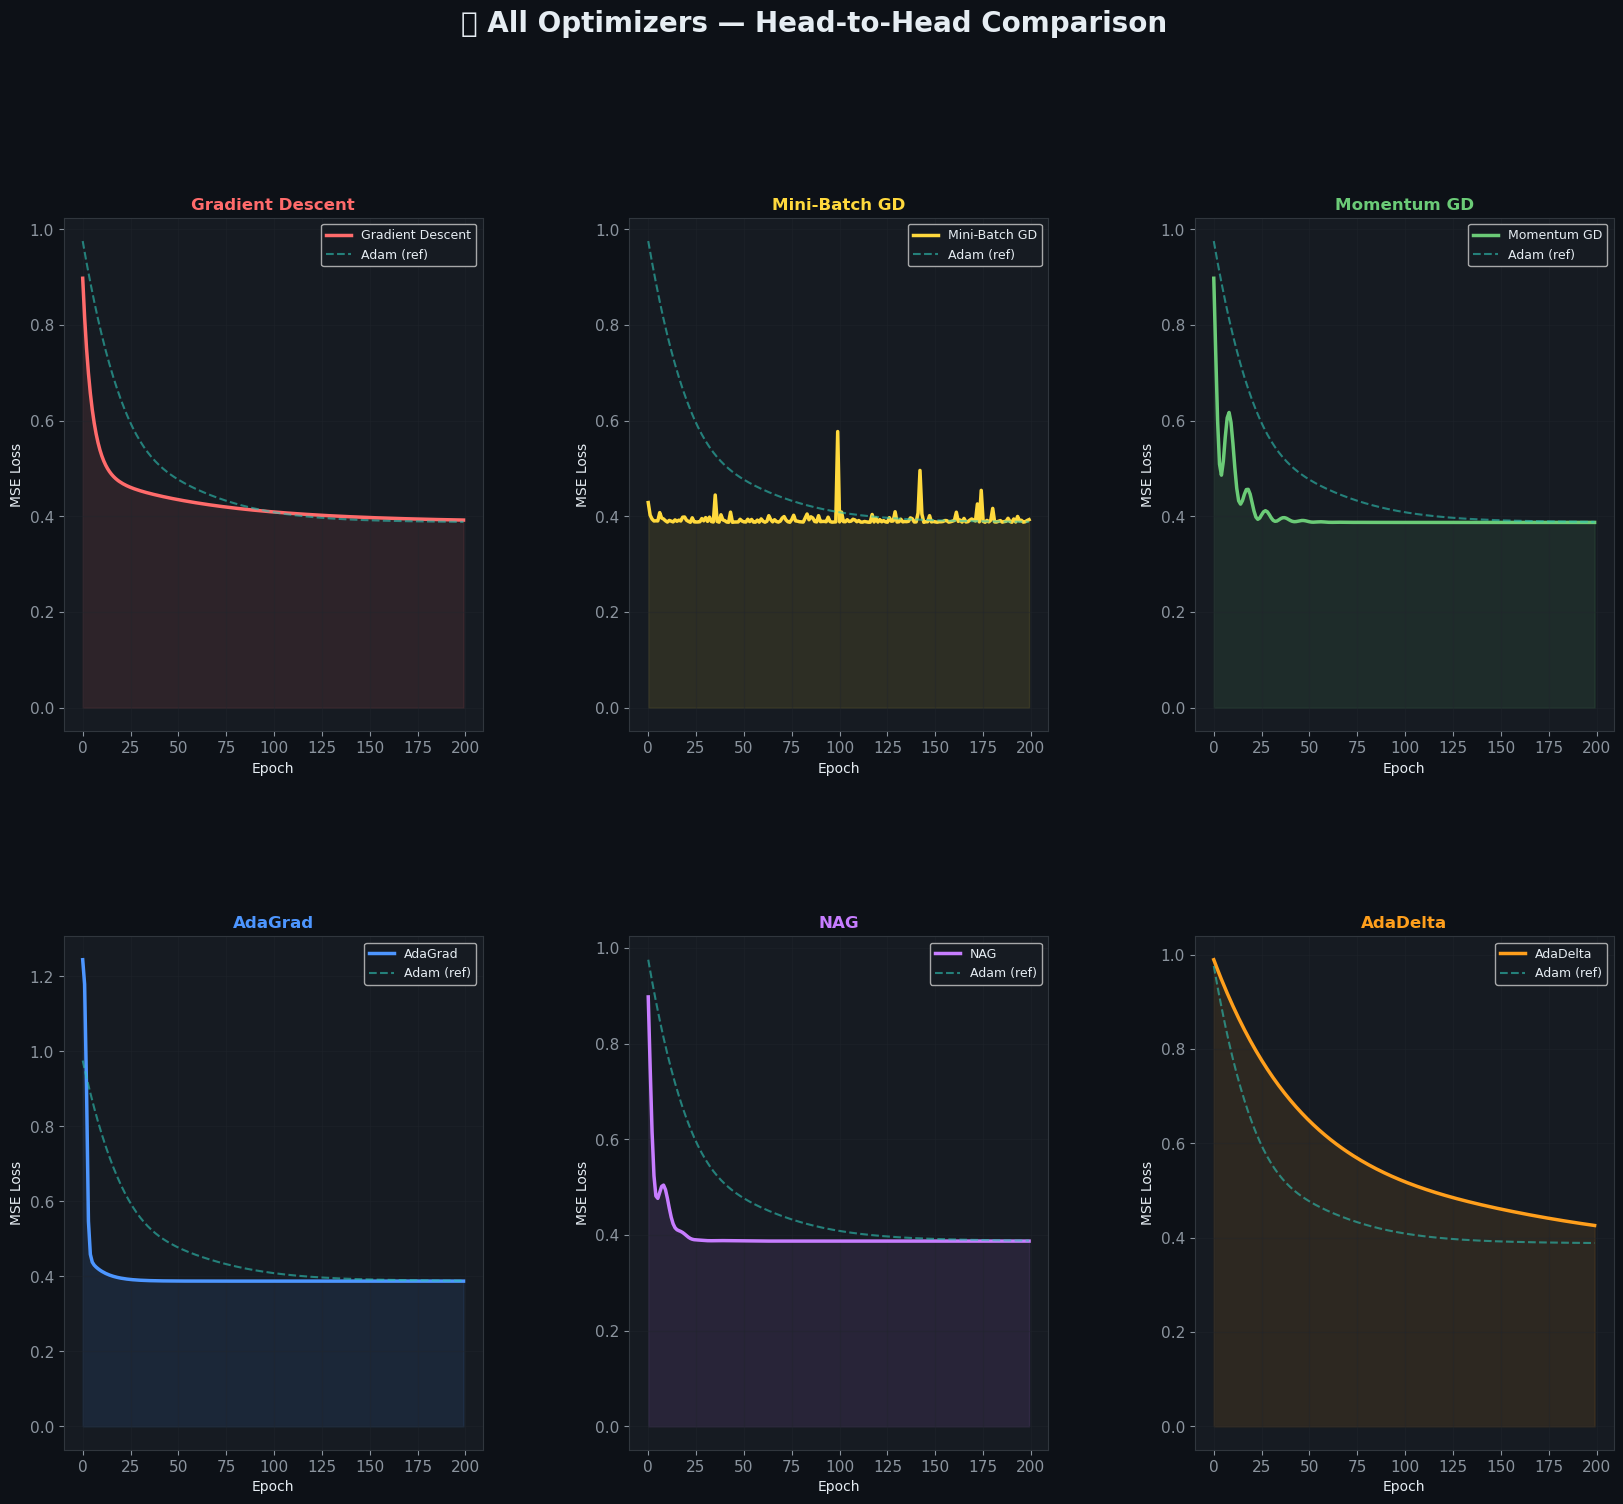

In [16]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('🏆 All Optimizers — Head-to-Head Comparison', fontsize=20, fontweight='bold', color='#e6edf3', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

algo_map = [
    ('GD',       train_gd,       'Gradient Descent'),
    ('BGD',      train_bgd,      'Mini-Batch GD'),
    ('Momentum', train_mom,      'Momentum GD'),
    ('AdaGrad',  train_ada,      'AdaGrad'),
    ('NAG',      train_nag,      'NAG'),
    ('AdaDelta', train_addelta,  'AdaDelta'),
]

positions = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]

for (key, train_l, title), (r, c) in zip(algo_map, positions):
    ax = fig.add_subplot(gs[r, c])
    color = COLORS[key]
    ax.plot(train_l,      color=color,        lw=2.5, label=title)
    ax.plot(train_adam,   color=COLORS['Adam'], lw=1.5, linestyle='--', alpha=0.6, label='Adam (ref)')
    ax.fill_between(range(EPOCHS), train_l, alpha=0.1, color=color)
    ax.set_title(title, fontweight='bold', fontsize=12, color=color)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('MSE Loss', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.savefig('/mnt/user-data/outputs/08_comparison_grid.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

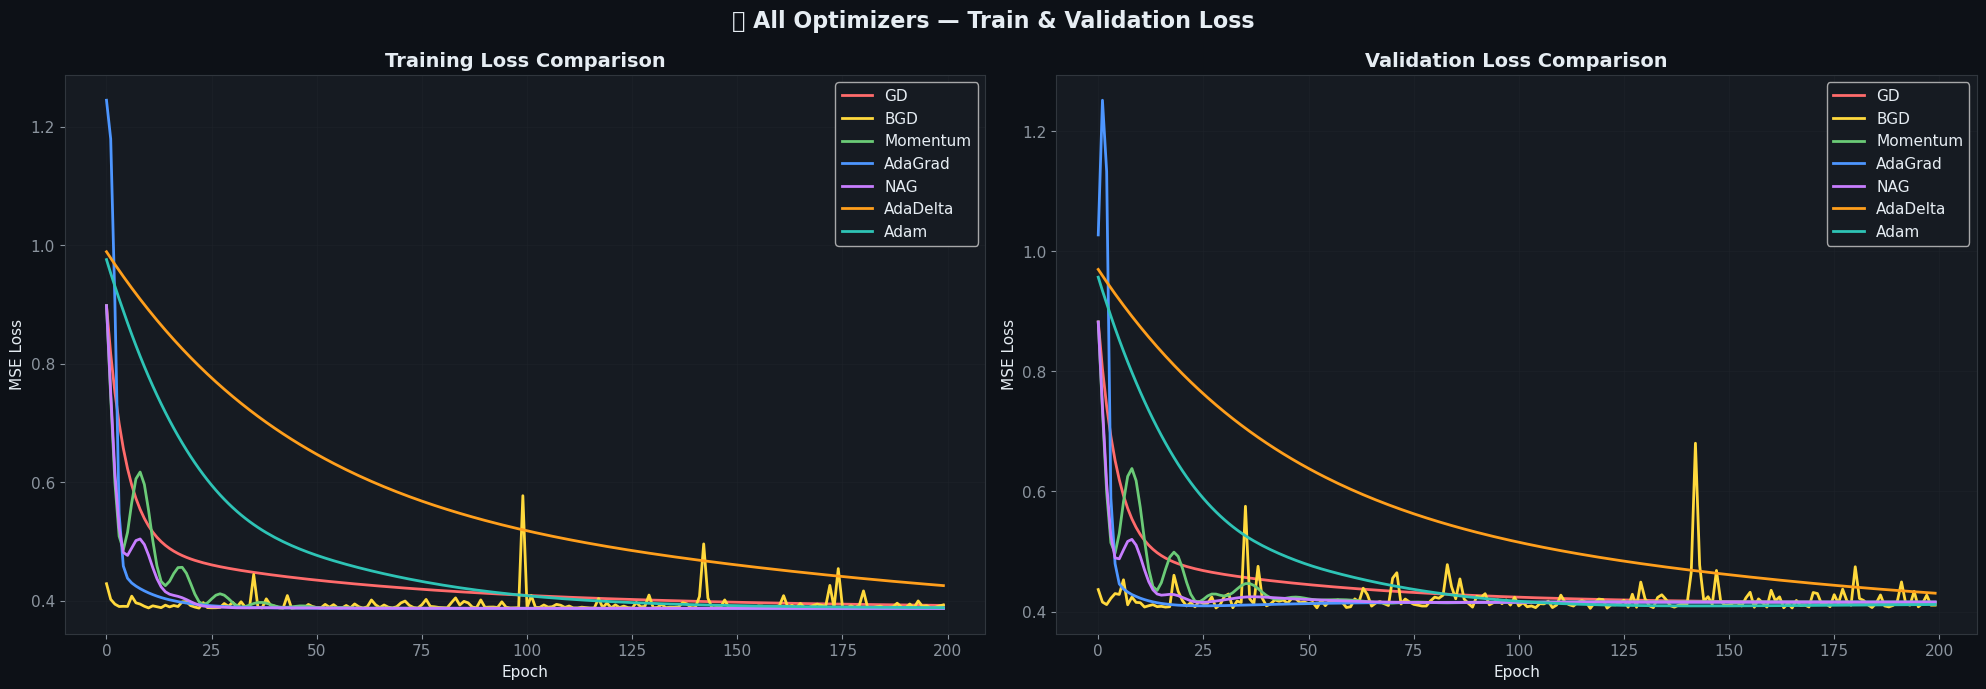

In [17]:
# All in one plot
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('🏆 All Optimizers — Train & Validation Loss', fontsize=16, fontweight='bold', color='#e6edf3')

curves = [
    ('GD',       train_gd,       val_gd),
    ('BGD',      train_bgd,      val_bgd),
    ('Momentum', train_mom,      val_mom),
    ('AdaGrad',  train_ada,      val_ada),
    ('NAG',      train_nag,      val_nag),
    ('AdaDelta', train_addelta,  val_addelta),
    ('Adam',     train_adam,     val_adam),
]

for key, train_l, val_l in curves:
    color = COLORS[key]
    axes[0].plot(train_l, color=color, lw=2, label=key)
    axes[1].plot(val_l,   color=color, lw=2, label=key)

axes[0].set_title('Training Loss Comparison', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.4)

axes[1].set_title('Validation Loss Comparison', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/09_all_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [18]:
# Summary Table
print('\n' + '='*80)
print(f"{'Algorithm':<15} {'Final Train Loss':>18} {'Final Val Loss':>16} {'Convergence Speed':>20}")
print('='*80)

data = [
    ('GD',       train_gd,       val_gd),
    ('BGD',      train_bgd,      val_bgd),
    ('Momentum', train_mom,      val_mom),
    ('AdaGrad',  train_ada,      val_ada),
    ('NAG',      train_nag,      val_nag),
    ('AdaDelta', train_addelta,  val_addelta),
    ('Adam',     train_adam,     val_adam),
]

for key, tr, vl in data:
    # Find epoch where loss dropped to 2x final
    threshold = min(tr) * 2
    conv_ep = next((i for i, v in enumerate(tr) if v < threshold), EPOCHS)
    print(f"{key:<15} {tr[-1]:>18.6f} {vl[-1]:>16.6f} {f'Epoch {conv_ep}':>20}")

print('='*80)
print('\n🏆 Best Optimizer: Adam (consistently fast convergence)')


Algorithm         Final Train Loss   Final Val Loss    Convergence Speed
GD                        0.392391         0.414861              Epoch 2
BGD                       0.393260         0.410725              Epoch 0
Momentum                  0.387449         0.415844              Epoch 1
AdaGrad                   0.387449         0.415843              Epoch 3
NAG                       0.387449         0.415844              Epoch 1
AdaDelta                  0.425768         0.430620             Epoch 15
Adam                      0.388630         0.411778             Epoch 11

🏆 Best Optimizer: Adam (consistently fast convergence)


---
## 📈 Bar Chart — Final Performance Summary

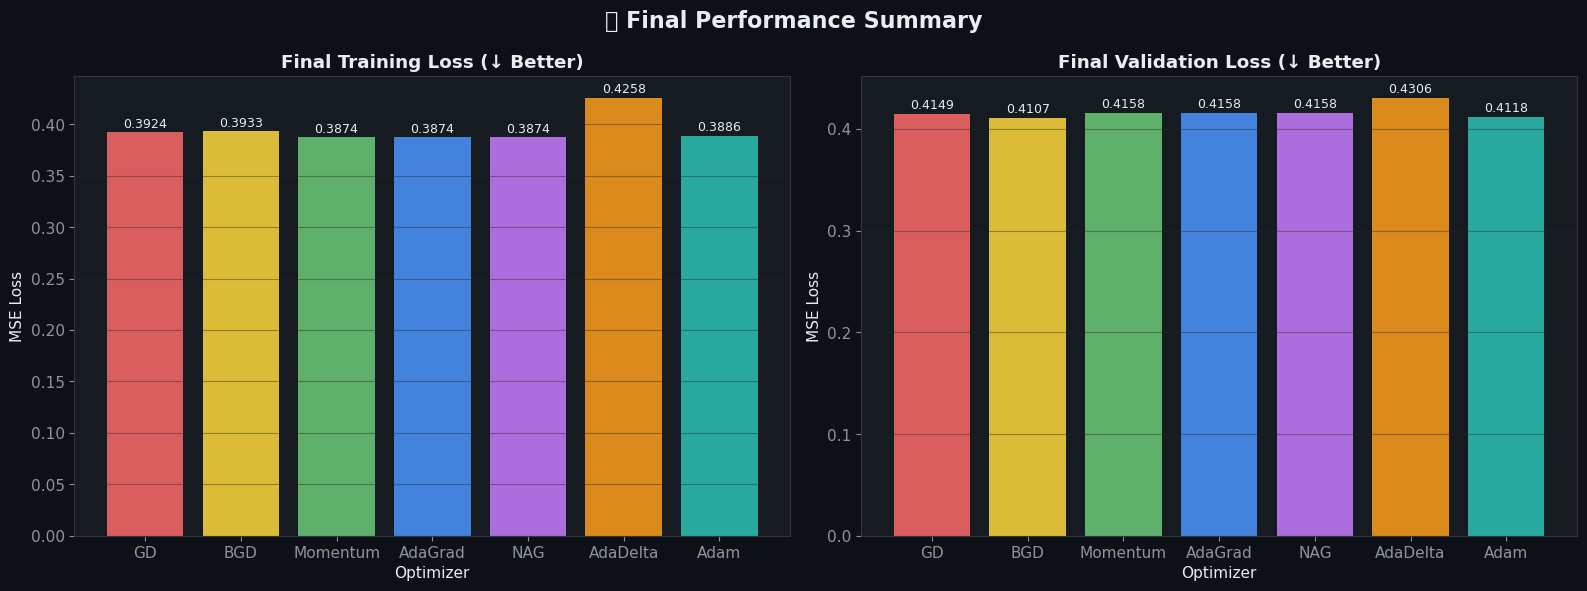


✅ All plots saved! Optimization study complete.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Final Performance Summary', fontsize=16, fontweight='bold', color='#e6edf3')

names  = ['GD', 'BGD', 'Momentum', 'AdaGrad', 'NAG', 'AdaDelta', 'Adam']
colors = [COLORS[n] for n in names]
finals_train = [train_gd[-1], train_bgd[-1], train_mom[-1], train_ada[-1], train_nag[-1], train_addelta[-1], train_adam[-1]]
finals_val   = [val_gd[-1],   val_bgd[-1],   val_mom[-1],   val_ada[-1],   val_nag[-1],   val_addelta[-1],   val_adam[-1]]

bars1 = axes[0].bar(names, finals_train, color=colors, alpha=0.85, edgecolor='none')
axes[0].set_title('Final Training Loss (↓ Better)', fontweight='bold')
axes[0].set_ylabel('MSE Loss'); axes[0].set_xlabel('Optimizer')
axes[0].grid(True, alpha=0.4, axis='y')
for bar, val in zip(bars1, finals_train):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, color='#e6edf3')

bars2 = axes[1].bar(names, finals_val, color=colors, alpha=0.85, edgecolor='none')
axes[1].set_title('Final Validation Loss (↓ Better)', fontweight='bold')
axes[1].set_ylabel('MSE Loss'); axes[1].set_xlabel('Optimizer')
axes[1].grid(True, alpha=0.4, axis='y')
for bar, val in zip(bars2, finals_val):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, color='#e6edf3')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/10_final_performance_bar.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n✅ All plots saved! Optimization study complete.')